In [1]:
import numpy as np
import networkx as nx
import pandas as pd
import geopandas as gpd
import osmnx as ox
import random
from matplotlib import pyplot as plt

from genesis.core import BestPointsBase, MetricBase, StateBase
from genesis.metrics import ArrivalTime, CoverIndex
from genesis.states import FirstArrivalUnitState
from genesis.tools import list_dict_concat
from genesis.swiss_knife import CMAP_GrGldRd
from genesis.utils import timing

In [2]:
# Загрузка графа и полигона границ
G = ox.load_graphml("tests/data/test_rng.ml")
area = gpd.read_file("tests/data/test_polygon.gpkg")

In [3]:
def iter_state_func(**kwds):
    '''
    Печать состояния расчета на итерации
    '''
    # print('Итерация:', kwds['i'])
    print(kwds)
    dynamic_nodes = kwds['dynamic_nodes']
    if isinstance(dynamic_nodes, dict):
        dynamic_nodes_id = list(dynamic_nodes.keys())
    else:
        dynamic_nodes_id = dynamic_nodes

    try:
        static_nodes = kwds['static_nodes']
        if isinstance(static_nodes, dict):
            static_nodes_id = list(static_nodes.keys())
        else:
            static_nodes_id = static_nodes
    except:
        static_nodes = None
        
    if not static_nodes is None:
        if isinstance(dynamic_nodes,list):
            start_nodes = dynamic_nodes+static_nodes
        elif isinstance(dynamic_nodes,dict):
            start_nodes = {**dynamic_nodes, **static_nodes}
    else:
        start_nodes = dynamic_nodes
    times, nearest = FirstArrivalUnitState()(env=G, points=start_nodes)
    times = {k:(1+int(t//5))*5 for k, t in times.items()}

    nx.set_node_attributes(G, pd.Series(nearest, dtype=str), 'nearest')
    nx.set_node_attributes(G, times, 'route_time')

    nds = ox.graph_to_gdfs(G, edges=False)
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
    ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax1)
    nds.plot(ax=ax1, markersize=2, column='nearest', cmap='Set3', legend=True)
    nds.loc[dynamic_nodes_id].plot(ax=ax1, markersize=25, color='red')
    if static_nodes:
        nds.loc[static_nodes_id].plot(ax=ax1, markersize=25, color='k')

    ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax2)
    nds.plot(ax=ax2, markersize=2, column='route_time', cmap=CMAP_GrGldRd, legend=True)
    nds.loc[dynamic_nodes_id].plot(ax=ax2, markersize=25, color='red')
    if static_nodes:
        nds.loc[static_nodes_id].plot(ax=ax2, markersize=25, color='k')

    plt.show()

In [4]:
class EpochEndFunction:
    def __init__(self):
        self.history=[]

    def __call__(self, **kwargs):
        print(kwargs, end='\r')
        self.history.append(kwargs)

In [14]:
class BestNodesGA(BestPointsBase):
    '''
    Поиск лучших узлов для размещения n объектов.

    Расчет производится генетическим алгоритмом.

    ## Область применения
    Определение размещения множества узлов в графе, при котором 
    обеспечиваются наилучшие некоторые целевые метрики. 
    
    ? Дает достаточно точное решение. Хорошо подходит для больших графов.
    '''

    def __init__(self,
                 state_function: StateBase,
                 metric_function: MetricBase,
                 population_size:int = 25,
                 epochs:int = 50,
                 mutation_rate:float = 0.1,
                 elite_size:int = 0,
                 appr_val_in_area:float = 0,
                 mutation_max_count:int = 1,
                 bad_val_in_area:int = 1000,
                 epoch_end_function:callable = None,
                 **kwargs) -> None:
        '''
        ## Аргументы
        `state_function`: StateBase
            функция расчета состояния окружения
        `metric_function`: MetricBase
            Функция расчета метрики
        `population_size`:int = 25
            Размер популяции
        `epochs`: int = 50
            Количество эпох расчета
        `mutation_rate`: float = 0.1
            Вероятность единичной мутации
        `elite_size`: int =  0
            Количество особей в элитной группе.
            Если указан 0, то механизм элитизма не задействуется.
        `appr_val_in_area`: int=0
            Доля узлов графа в пределах area, покрытие которой считается приемлемой для принятия расчетной метрики. 
            Если при расчете метрик, из стартового узла (узлов) достижимо меньшее количество узлов,
            то такой узел не рассматривается.
            При расчет размещения нескольких узлов неминуемо возникает ситуация при которой
            часть территории area будет недостижима. Поэтому по умолчанию считается
        `mutation_max_count`: int = 1
            Максимальное количество единиц мутации.
        `bad_val_in_area`: int=1000
            Значение указываемое для узла, в случае если
            из него нельзя попасть в `appr_val_in_area` долю узлов в пределах
            `area`.
        `epoch_end_function`: callable = None
            Функция вызываемая после каждой эпохи расчета.
        '''
        if population_size <= 5:
            raise ValueError('Размер популяции должен быть > 0, так же не рекомендуется использовать размер популяции < 5')
        if epochs  <=  0:
            raise ValueError('Количество эпох должно быть > 0')
        if mutation_max_count  <=  0:
            raise ValueError('Максимальное количество единиц мутации должно быть > 0')
        if mutation_rate <0 or mutation_rate > 1:
            raise ValueError('Вероятность мутации должна лежать в диапазоне (0,1)')
        if appr_val_in_area <0 or appr_val_in_area > 1:
            raise ValueError('Доля узлов графа в пределах area, должна лежать в диапазоне (0,1)')
        if elite_size < 0:
            raise ValueError('Количество особей в элитной группе должно быть >= 0')
        
        self.population_size = population_size
        self.epochs = epochs
        self.mutation_rate = mutation_rate
        self.elite_size = elite_size
        self.appr_val_in_area = appr_val_in_area
        self.mutation_max_count = mutation_max_count
        self.bad_val_in_area = bad_val_in_area
        self.epoch_end_function = epoch_end_function
        super().__init__(state_function, metric_function, **kwargs)

    def _fit_function(self, env, nodes, area=None, **kwargs):
        '''
        Расчет функции приспособленности
        '''
        # 2.1. Расчет состояния
        times, _ = self.state_function(env=env, points=nodes, area=area, **kwargs)

        if not area is None:
            appr_nodes_count = area.sum() * self.appr_val_in_area
            if len(times) < appr_nodes_count:
                print('Расстановка не обеспечивает требуемую степень прикрытия территории area')
                return self.bad_val_in_area

        # 2.2. Расчет стартовой метрики состояния и определение стартового размещения
        best_metric = self.metric_function(times, **kwargs)

        return best_metric


    def __call__(self,
                 env:nx.MultiDiGraph,
                 dynamic_nodes: dict,
                 static_nodes: dict = None,
                 area: pd.Series = None,
                 **kwargs):
        '''
        Запуск работы генетического алгоритма

        ## Аргументы
        `env`:nx.MultiDiGraph
            Граф улично-дорожной сети
        `dynamic_nodes`: list|dict
            Список стартовых узлов графа в которых размещены
            подразделения оптимальные места которых следует определить.
        `static_nodes`: list|dict = None
            Список стартовых узлов графа в которых размещены
            подразделения изменять размещение которых не следует.
        `area`: pd.Series = None
            Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
            Если не указана, расчет производится для всех узлов графа.
        '''
        
        # 0. Проверка корректности пришедших данных
        if not isinstance(env, nx.MultiDiGraph):
            raise TypeError("Тип аргумента `env` должен быть MultiDiGraph!")
        if not isinstance(dynamic_nodes, dict):
            raise TypeError("Тип аргумента `dynamic_nodes` должен быть dict!")
        if not static_nodes is None and not isinstance(static_nodes, dict):
            raise TypeError("Тип аргумента `static_nodes` должен быть dict!")
        if len(dynamic_nodes)<2:
            raise ValueError(f'Количество элементов `dynamic_nodes` не может быть меньше 2. Сейчас {len(dynamic_nodes)}')
        if not area is None and not isinstance(area, pd.Series):
            raise TypeError(f'Аргумент `area` должен иметь тип `pd.Series`! Имеет {type(area)}')


        # 1.1. Если статические узлы не указаны - заменяем значение переменной с None
        # на [] или {} в зависимости от типа данных `dynamic_nodes`
        if static_nodes is None:
            static_nodes = {}

        # Последовательность узлов графа (для последующего обращения к нему)
        g_nodes = list(env.nodes())

        # ===================================== Генетический алгоритм ==============
        # 1. Создание стартовой популяции
        population = [dynamic_nodes for _ in range(self.population_size)]
        # Оценка приспособленности всех особей
        bot_fit = [self._fit_function(env=env,
                                      nodes=list_dict_concat(dn, static_nodes),
                                      area=area,
                                      **kwargs) for dn in population]
        if self.metric_function.compare(1,2)==1:        # Для минимизации:
            max_val  = max(bot_fit)
            weights = [1.1*max_val-x for x in bot_fit]
            best_metric = min(bot_fit)
        else:                                           # Для максимизации:
            weights = bot_fit
            best_metric = max(bot_fit)
        best_bot = population[bot_fit.index(best_metric)]
        
        # 2. На каждой эпохе
        for epoch in range(self.epochs):

            new_population = []
            # Генерация новой популяции
            for _ in range(self.population_size):
                # Элитарность
                if self.elite_size>0:
                    # Определение весов
                    pop_weight = pd.DataFrame({'w': weights, 'p': population})
                    pop_weight = pop_weight.sort_values('w', ascending=False)
                    pop_weight = pop_weight[:self.elite_size]
                    population = pop_weight['p'].to_list()
                    weights = pop_weight['w'].to_list()

                # Отбор по правилу рулетки
                parent_bot_1 = random.choices(population, weights=weights)[0]
                parent_bot_2 = random.choices(population, weights=weights)[0]

                # Скрещивание (одноточечное)
                split_point = int(len(parent_bot_1)/2)
                left_gen_vals = list(parent_bot_1.values())[:split_point]
                right_gen_vals  = list(parent_bot_1.values())[split_point:]
                left_genome_part = {k:v for k, v in parent_bot_1.items() if v in left_gen_vals}
                right_genome_part = {k:v for k, v in parent_bot_2.items() if v in right_gen_vals}
                new_dynamic_nodes = {**left_genome_part, **right_genome_part}

                # Мутация (выбор произвольного узла)
                for _ in range(self.mutation_max_count):
                    if random.random() < self.mutation_rate:
                        # Выбор случайного элемента в словаре и удаление его из new_dynamic_nodes
                        node, unit = random.choice(list(new_dynamic_nodes.items()))
                        del new_dynamic_nodes[node]

                        # Поиск нового узла, котрого при этом нет в new_dynamic_nodes
                        node = random.choice(g_nodes)
                        while node in new_dynamic_nodes.keys():
                            node = random.choice(g_nodes)

                        new_dynamic_nodes[node] = unit

                        # print(node, unit, new_dynamic_nodes)

                # Добавляем его в новую популяцию
                new_population.append(new_dynamic_nodes)

            # Заменяем предыдущую популяцию новой
            population = new_population
            
            # Оценка приспособленности всех особей
            bot_fit = [self._fit_function(env=env,
                                      nodes=list_dict_concat(dn, static_nodes),
                                      area=area,
                                      **kwargs) for dn in population]

            # Определение лучшего на эпохе значения метрики
            # и весов в зависимости от приспособленности        
            if self.metric_function.compare(1,2)==1:    # Для минимизации:
                max_val  = max(bot_fit)
                weights = [max_val-x for x in bot_fit]
                cur_metric = min(bot_fit)
            else:                                       # Для максимизации
                weights = bot_fit
                cur_metric = max(bot_fit)
            # Нормализация весов (для более выраженной точности расчета)
            weights = (weights - np.min(weights)) / (np.max(weights) - np.min(weights))
            
            # Определяем лучше ли лучшее на эпохе решение чем имеющееся
            if self.metric_function.compare(best_metric, cur_metric) == cur_metric:
                best_bot = population[bot_fit.index(cur_metric)]
                best_metric  = cur_metric

            # Выполнение функции окончания расчета на эпохе
            if self.epoch_end_function:
                self.epoch_end_function(epoch=epoch,
                                        best_metric=best_metric,
                                        cur_metric=cur_metric,
                                        best_bot=best_bot)


        return  best_bot, best_metric


def epoch_end_function(epoch, best_metric, cur_metric, **kwargs):
    print(f'Эпоха: {epoch} |', f'Лучшая метрика: {best_metric} |', f'Текущая метрика: {cur_metric} |')

eef = EpochEndFunction()


nodes = list(G.nodes())
existed_units = {nodes[200]:'A', 
                nodes[2000]:'B', 
                }
new_units = {nodes[3000]:'c',
             nodes[4000]:'d'}
ns = ox.graph_to_gdfs(G, edges=False)
points_mask = ns.within(area.iloc[0].geometry)


BNGA = timing(BestNodesGA(FirstArrivalUnitState(),
                #    ArrivalTime(),
                   CoverIndex(5),
                   population_size=20,
                #    elite_size=20,
                   epochs=25,
                   mutation_rate=0.5,
                   nutation_max_count=3,
                   epoch_end_function=eef,
                   ))

optimal_nodes, best_metric = BNGA(env=G, 
                                  static_nodes=existed_units, 
                                  dynamic_nodes=new_units,
                                  area=points_mask,
                                  )

# # Печать карт размещения и прибытия
# iter_state_func(dynamic_nodes=optimal_nodes, static_nodes=existed_units)

ВРЕМЯ: 32.23 секest_metric': 89.22664282521234, 'cur_metric': 80.5543138131426, 'best_bot': {1550084436: 'd', 4116050695: 'c'}}}


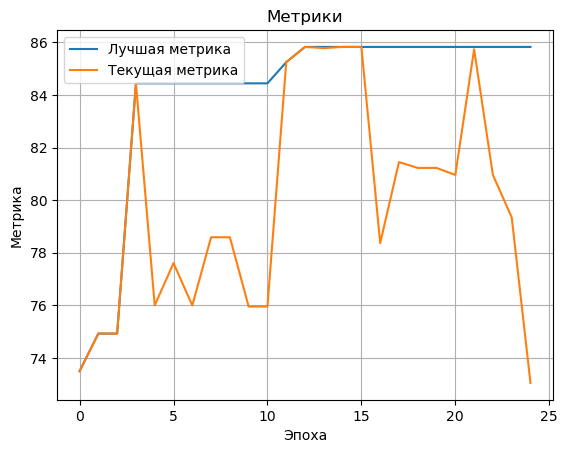

In [12]:
df = pd.DataFrame(eef.history)   #['best_metric'].plot()

fig, ax  = plt.subplots(1,1)
ax.plot(range(len(df)), df['best_metric'], label='Лучшая метрика')
ax.plot(range(len(df)), df['cur_metric'], label='Текущая метрика')
ax.legend()
ax.set_xlabel('Эпоха')
ax.set_ylabel('Метрика')
ax.set_title('Метрики')
ax.grid()

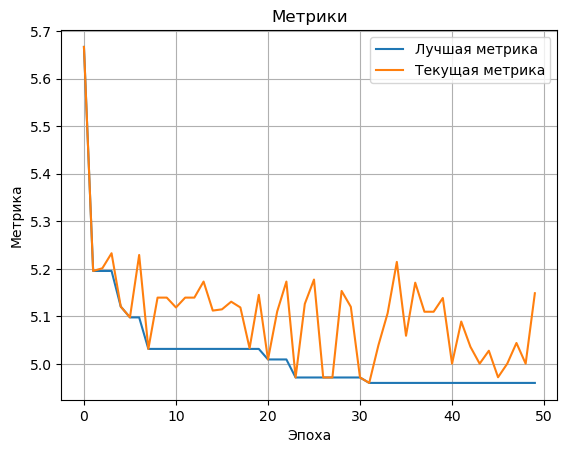

In [23]:
df = pd.DataFrame(eef.history)   #['best_metric'].plot()

fig, ax  = plt.subplots(1,1)
ax.plot(range(len(df)), df['best_metric'], label='Лучшая метрика')
ax.plot(range(len(df)), df['cur_metric'], label='Текущая метрика')
ax.legend()
ax.set_xlabel('Эпоха')
ax.set_ylabel('Метрика')
ax.set_title('Метрики')
ax.grid()

In [8]:
start_nodes = {**optimal_nodes, **existed_units}
times, _ = FirstArrivalUnitState()(env=G, points=start_nodes, area=points_mask)
best_metric = ArrivalTime()(times)
best_metric

4.373901859346063

{'dynamic_nodes': {9085465242: 'd', 2034401903: 'c'}, 'static_nodes': {1526100295: 'A', 2042076750: 'B'}}


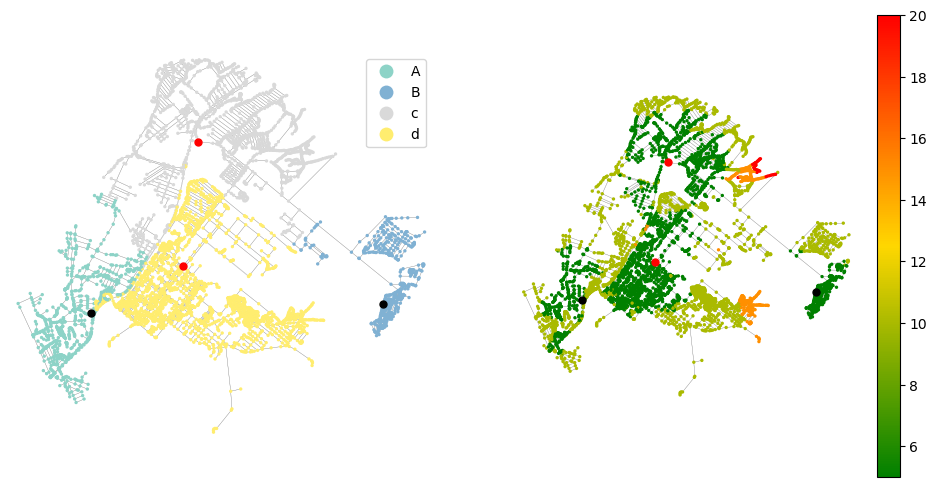

In [9]:
# Печать карт размещения и прибытия
iter_state_func(dynamic_nodes=optimal_nodes, static_nodes=existed_units)

<Axes: >

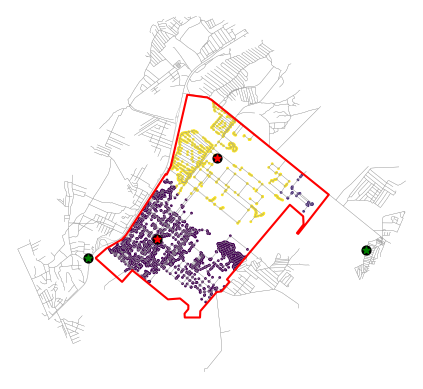

In [13]:
all_nodes = {**optimal_nodes, **existed_units}

ns = ox.graph_to_gdfs(G, edges=False)
points_mask = ns.within(area.iloc[0].geometry)

times, nearest = FirstArrivalUnitState()(env=G, points=list(all_nodes.keys()), area=points_mask)

ns['nearest'] = nearest

ax = ns[ns['nearest'].notna()].plot(markersize=1, column='nearest')
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax)
area.boundary.plot(ax=ax, color='r')
ns.loc[all_nodes.keys()].plot(ax=ax, markersize=40, color='k')
ns.loc[optimal_nodes.keys()].plot(ax=ax, markersize=25, color='red', marker="*")
ns.loc[existed_units.keys()].plot(ax=ax, markersize=25, color='green', marker="*")

## Для множества точек

In [169]:
nodes = list(G.nodes())
existed_units = {nodes[100]:'A', 
                nodes[2000]:'B', 
                }
new_units = {nodes[1000]:'a',
             nodes[2000]:'b',
             nodes[3000]:'c',
             nodes[4000]:'d',
             nodes[4500]:'e',
             nodes[5000]:'f',}


BNGA = timing(BestNodesGA(FirstArrivalUnitState(),
                   ArrivalTime(),
                   population_size=100,
                   elite_size=20,
                   epochs=20,
                   mutation_rate=0.5,
                   epoch_end_function=epoch_end_function))

optimal_nodes, best_metric = BNGA(env=G, 
                                #   static_nodes=existed_units, 
                                  dynamic_nodes=new_units
                                  )

Эпоха: 0 | Лучшая метрика: 4.686815067249793 | Текущая метрика: 4.686815067249793 |
Эпоха: 1 | Лучшая метрика: 4.553574308671616 | Текущая метрика: 4.553574308671616 |
Эпоха: 2 | Лучшая метрика: 4.543114780795785 | Текущая метрика: 4.543114780795785 |
Эпоха: 3 | Лучшая метрика: 4.486883515689888 | Текущая метрика: 4.486883515689888 |
Эпоха: 4 | Лучшая метрика: 4.486883515689888 | Текущая метрика: 4.486883515689888 |
Эпоха: 5 | Лучшая метрика: 4.486883515689888 | Текущая метрика: 4.49309899438071 |
Эпоха: 6 | Лучшая метрика: 4.486883515689888 | Текущая метрика: 4.49309899438071 |
Эпоха: 7 | Лучшая метрика: 4.483808739085859 | Текущая метрика: 4.483808739085859 |
Эпоха: 8 | Лучшая метрика: 4.427327154069767 | Текущая метрика: 4.427327154069767 |
Эпоха: 9 | Лучшая метрика: 4.427327154069767 | Текущая метрика: 4.427327154069767 |
Эпоха: 10 | Лучшая метрика: 4.427327154069767 | Текущая метрика: 4.427327154069767 |
Эпоха: 11 | Лучшая метрика: 4.421173934956395 | Текущая метрика: 4.4211739349

{'dynamic_nodes': {2034401706: 'a', 2042076750: 'b', 1545630478: 'e', 2054468566: 'c', 4796091625: 'f', 2034402452: 'd'}}


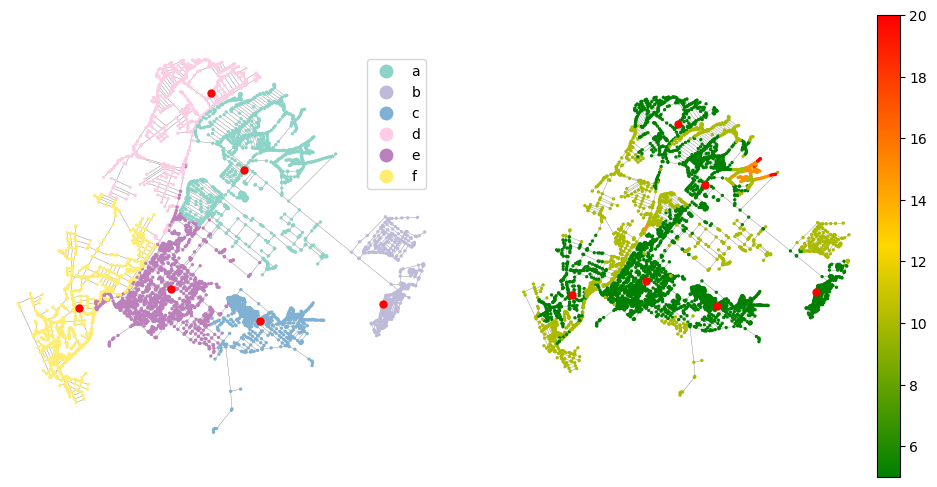

In [170]:
# Печать карт размещения и прибытия
iter_state_func(dynamic_nodes=optimal_nodes)

# Расчет для Красноярского графа

In [4]:
from genesis.tools import kmh_to_mm


G = ox.graph_from_place('Красноярск, Россия')
print(G.number_of_nodes())

s1, s2, s3, s4, s5 = [49, 37, 26, 16, 5]
hwy_speeds = {
            "trunk":          s1,           # Важные дороги, не являющиеся автомагистралями
            "trunk_link":     s1,           # Важные дороги, не являющиеся автомагистралями
            "motorway":       s1,           # Автомагистрали 
            "motorway_link":  s1,           # Автомагистрали 
            
            "primary":        s2,           # Автомобильные дороги регионального значения
            "primary_link":   s2,           # Автомобильные дороги регионального значения
            "secondary":      s2,           # Автомобильные дороги областного значения
            "secondary_link": s2,           # Автомобильные дороги областного значения
            "unclassified":   s2,           # Остальные автомобильные дороги местного значения, образующие соединительную сеть дорог.

            "tertiary":       s3,           # Более важные автомобильные дороги среди прочих автомобильных дорог местного значения
            "tertiary_link":  s3,           # Более важные автомобильные дороги среди прочих автомобильных дорог местного значения
            "residential":    s3,           # Дороги, которые проходят внутри жилых зон, а также используются для подъезда к ним
            "living_street":  s3,           # Жилые зоны и дворовые проезды
            
            "road":           s4,           # Линии, возможно, являющиеся дорогами. Временный тег, которым следует помечать линии до уточнения.
            "service":        s4,           # Служебные проезды: внутриквартальные, въездные, парковочные и т.д.
            "track":          s4,           # Дороги сельскохозяйственного назначения, лесные дороги, не ведущие к жилым или промышленным объектам, неофициальные грунтовки, козьи тропы
            
            "footway":        s5,           # Пешеходные дорожки, тротуары. 
            "path":           s5,           # Тропа (чаще всего, стихийная) использующаяся пешеходами, либо одним или несколькими видами транспорта, кроме четырехколесного (лыжи, снегоход, велосипед).
            "pedestrian":     s5,           # Для обозначения улиц городов (такого же класса как residential), выделенных для пешеходов.
            
            "steps":          s5,           # Лестницы, лестничные пролёты. 
            "cycleway":       s5,           # Велодорожка, обозначенная соответствующим дорожным знаком. 
            "bridleway":      s5,           # Дорожки для верховой езды.
            "corridor":       s5,           # Коридоры внутри крупных зданий
}

hwy_speeds = {k: kmh_to_mm(v) for k,v in hwy_speeds.items()}

defSpeed=5
for edge in G.edges:
    road = G.get_edge_data(*edge).get('highway')
    length = G.get_edge_data(*edge).get('length')

    try:
        speed = hwy_speeds.get(road, defSpeed)
    except TypeError: # Тип дороги бывает списком, обычно ['residential', 'сервис']
        if isinstance(road, list):
            speed = hwy_speeds.get(road[0], defSpeed)
        else:
            speed = defSpeed

    G.add_edge(*edge, travel_time=length/speed)

46914


In [5]:
nodes = list(G.nodes())
new_units = {
            nodes[500]:'псч-1',
            nodes[1000]:'псч-2',
            nodes[2000]:'псч-3',
            nodes[3000]:'псч-4',
            nodes[4000]:'псч-5',
            nodes[5000]:'псч-6',
            nodes[6000]:'псч-7',
            nodes[7000]:'псч-8',
            }

In [6]:
BNGA = timing(BestNodesGA(FirstArrivalUnitState(),
                   ArrivalTime(),
                   population_size=50,
                   elite_size=15,
                   epochs=20,
                   mutation_rate=0.5,
                   epoch_end_function=epoch_end_function))

optimal_nodes, best_metric = BNGA(env=G, 
                                  dynamic_nodes=new_units
                                  )

Эпоха: 0 | Лучшая метрика: 9.201025151783613 | Текущая метрика: 9.201025151783613 |
Эпоха: 1 | Лучшая метрика: 8.904861713979093 | Текущая метрика: 8.904861713979093 |
Эпоха: 2 | Лучшая метрика: 8.735161427313884 | Текущая метрика: 8.735161427313884 |
Эпоха: 3 | Лучшая метрика: 8.595359405477298 | Текущая метрика: 8.595359405477298 |
Эпоха: 4 | Лучшая метрика: 8.521583742420143 | Текущая метрика: 8.521583742420143 |
Эпоха: 5 | Лучшая метрика: 8.349960349501336 | Текущая метрика: 8.349960349501336 |
Эпоха: 6 | Лучшая метрика: 8.349960349501336 | Текущая метрика: 8.349960349501336 |
Эпоха: 7 | Лучшая метрика: 8.146755528858867 | Текущая метрика: 8.146755528858867 |
Эпоха: 8 | Лучшая метрика: 8.146755528858867 | Текущая метрика: 8.146755528858867 |
Эпоха: 9 | Лучшая метрика: 8.146755528858867 | Текущая метрика: 8.203871592683168 |
Эпоха: 10 | Лучшая метрика: 8.146755528858867 | Текущая метрика: 8.185307498987397 |
Эпоха: 11 | Лучшая метрика: 8.146755528858867 | Текущая метрика: 8.18530749

{'dynamic_nodes': {457310528: 'псч-3', 356313823: 'псч-1', 7100783963: 'псч-7', 3876393437: 'псч-8', 9207846156: 'псч-4', 2414156898: 'псч-6', 8789288109: 'псч-5', 3244608154: 'псч-2'}}


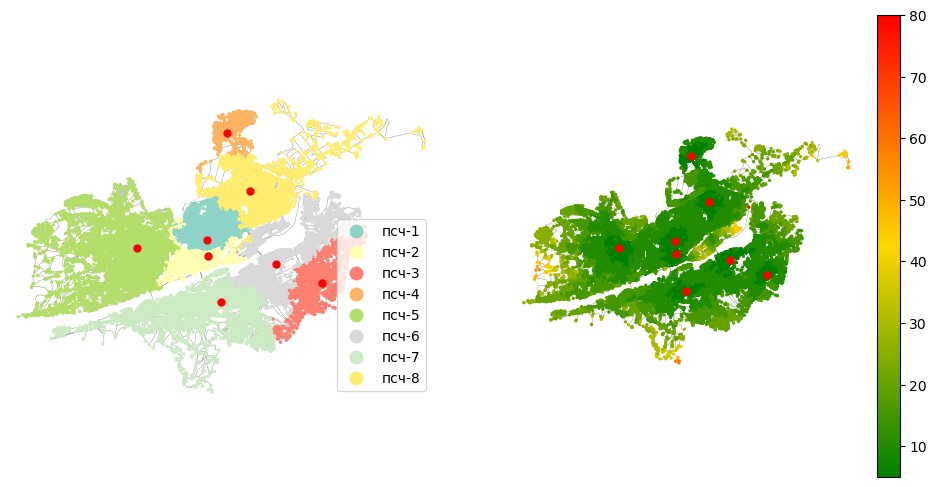

In [8]:
# Печать карт размещения и прибытия
iter_state_func(dynamic_nodes=optimal_nodes)  #, static_nodes=existed_units)